<a href="https://colab.research.google.com/github/Maria-lin/F1-Analytics/blob/main/detection_anomalieskmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏧 Détection d'Anomalies sur le Réseau GAB
## Identification automatique des comportements atypiques sur les Guichets Automatiques Bancaires

---

> **Destinataires :** Experts métier – Responsables réseau GAB  
> **Objectif :** Identifier automatiquement les GAB au comportement inhabituel, sans étiquette préalable  
> **Approche :** Détection d'anomalies non supervisée (Isolation Forest)

---

## 1. 🏦 Introduction Métier

### Pourquoi surveiller le comportement des GAB ?

Un **Guichet Automatique Bancaire (GAB)** est bien plus qu'une simple machine à billets.  
Chaque jour, il enregistre des centaines d'opérations : retraits, refus, captures de carte…  
L'ensemble de ces comportements forme une **empreinte** propre à chaque automate.

**Un GAB "normal"** présente :
- Un volume de retraits stable, cohérent avec son emplacement (centre-ville vs zone rurale)
- Un taux de capture de carte bas (les cartes capturées indiquent des incidents)
- Des montants moyens dans une plage raisonnable
- Une activité rythmée par la saisonnalité (fêtes, été…)

**Un GAB "atypique"** peut révéler :
- 🔴 Un problème technique (pannes, captures anormalement fréquentes)
- 🔴 Une fraude en cours (montants suspects, activité nocturne inhabituelle)
- 🔴 Un dysfonctionnement réseau (cartes d'un seul type concentrées sur un automate)
- 🔴 Un comportement client inhabituel (retraits massifs, activité hors horaires)

### Pourquoi un modèle ?

> *« Les anomalies évidentes, on les voit déjà. »*

C'est vrai. Mais le modèle détecte ce que l'œil humain ne peut pas voir :
- Des **combinaisons** subtiles de signaux faibles (montant moyen légèrement élevé + taux capture légèrement haut + activité nocturne légèrement supérieure = anomalie)
- Des anomalies sur **100+ variables simultanément**
- Une **surveillance continue** sur l'ensemble du parc, sans fatigue

---

## 2. ⚙️ Imports et Configuration

In [1]:
# ── Librairies standards ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import MarkerCluster, HeatMap

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats as scipy_stats

# ── Style global ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COULEUR_NORMAL   = '#2196F3'   # bleu
COULEUR_ANOMALIE = '#F44336'   # rouge
COULEUR_ACCENT   = '#FF9800'   # orange

print('✅ Librairies chargées avec succès.')


✅ Librairies chargées avec succès.


## 3. 📂 Chargement des Données

Le dataset **`fiche_identite_gab`** contient une ligne par GAB et par mois.  
Chaque ligne résume l'activité complète de l'automate sur la période.

In [4]:
import numpy as np
import pandas as pd

# ── Chargement du dataset ─────────────────────────────────────────────────────
# Adapter le chemin selon votre environnement Dataiku ou local
# df = pd.read_csv('fiche_identite_gab.csv')
# df = dataiku.Dataset('fiche_identite_gab').get_dataframe()  # Dataiku

# ── Simulation de données réalistes pour démonstration ───────────────────────
np.random.seed(42)

n_normal = 450
n_anomalie = 30
N = n_normal + n_anomalie

periodes = pd.date_range('2024-01-01', periods=12, freq='MS')

def generer_dataset(n_normal=450, n_anomalie=30):
    # GAB normaux
    df_normal = pd.DataFrame({
        'num_automate': [f'GAB_{i:04d}' for i in range(n_normal)],
        'annee': np.random.choice([2024, 2025], n_normal),
        'mois': np.random.randint(1, 13, n_normal),
        'ret_nb': np.random.normal(800, 150, n_normal).clip(100),
        'ret_montant_total': np.random.normal(120000, 25000, n_normal).clip(5000),
        'ret_montant_moyen': np.random.normal(150, 30, n_normal).clip(50),
        'ret_montant_max': np.random.normal(500, 80, n_normal).clip(200),
        'ret_montant_stddev': np.random.normal(60, 15, n_normal).clip(5),
        'ret_nb_nuit': np.random.normal(80, 25, n_normal).clip(0),
        'ret_nb_weekend': np.random.normal(180, 40, n_normal).clip(0),
        'ret_pct_nuit': np.random.normal(10, 3, n_normal).clip(0, 100),
        'ret_pct_weekend': np.random.normal(22, 5, n_normal).clip(0, 100),
        'cap_nb': np.random.poisson(4, n_normal),
        'taux_capture_pct': np.random.normal(0.5, 0.3, n_normal).clip(0),
        'nb_ope_reseau_Franfinance': np.random.normal(30, 10, n_normal).clip(0),
        'nb_ope_reseau_CB': np.random.normal(350, 60, n_normal).clip(0),
        'nb_ope_reseau_Trionis': np.random.normal(15, 8, n_normal).clip(0),
        'nb_ope_reseau_PPL': np.random.normal(12, 6, n_normal).clip(0),
        'nb_ope_reseau_Mastercard': np.random.normal(120, 30, n_normal).clip(0),
        'nb_ope_reseau_Configona': np.random.normal(8, 4, n_normal).clip(0),
        'nb_ope_reseau_Interne': np.random.normal(80, 20, n_normal).clip(0),
        'nb_ope_reseau_Casino': np.random.normal(10, 5, n_normal).clip(0),
        'nb_ope_reseau_Accord': np.random.normal(25, 10, n_normal).clip(0),
        'nb_ope_reseau_Visa': np.random.normal(180, 40, n_normal).clip(0),
        'nb_ope_reseau_COS': np.random.normal(6, 3, n_normal).clip(0),
        'nb_ope_reseau_JCB': np.random.normal(4, 3, n_normal).clip(0),
        'nb_ope_reseau_PostEpargne': np.random.normal(5, 3, n_normal).clip(0),
        'nb_ope_reseau_Diners_et_Discovery': np.random.normal(3, 2, n_normal).clip(0),
        'nb_ope_reseau_autres': np.random.normal(10, 5, n_normal).clip(0),
        'type_gab_e_i': np.random.choice(['Interne', 'Externe'], n_normal, p=[0.4, 0.6]),
        'code_postal': np.random.choice(['75001', '69001', '13001', '33000', '31000', '59000'], n_normal),
        'longitude': np.random.uniform(-4.5, 8.2, n_normal),
        'latitude': np.random.uniform(42.3, 51.1, n_normal),
        'is_anomalie_reelle': 0
    })

    # Construction robuste de ret_nb pour les anomalies
    n_haut = n_anomalie // 2
    n_bas = n_anomalie - n_haut

    ret_nb_anomalie = np.concatenate([
        np.random.normal(1800, 200, n_haut),
        np.random.normal(100, 30, n_bas)
    ])
    np.random.shuffle(ret_nb_anomalie)
    ret_nb_anomalie = ret_nb_anomalie.clip(0)

    # GAB atypiques (anomalies injectées)
    df_anomalie = pd.DataFrame({
        'num_automate': [f'GAB_ANOM_{i:03d}' for i in range(n_anomalie)],
        'annee': np.random.choice([2024, 2025], n_anomalie),
        'mois': np.random.randint(1, 13, n_anomalie),
        'ret_nb': ret_nb_anomalie,
        'ret_montant_total': np.random.normal(350000, 60000, n_anomalie).clip(1000),
        'ret_montant_moyen': np.random.normal(420, 80, n_anomalie).clip(100),
        'ret_montant_max': np.random.normal(1200, 200, n_anomalie).clip(300),
        'ret_montant_stddev': np.random.normal(180, 40, n_anomalie).clip(5),
        'ret_nb_nuit': np.random.normal(250, 60, n_anomalie).clip(0),
        'ret_nb_weekend': np.random.normal(500, 80, n_anomalie).clip(0),
        'ret_pct_nuit': np.random.normal(35, 8, n_anomalie).clip(0, 100),
        'ret_pct_weekend': np.random.normal(45, 8, n_anomalie).clip(0, 100),
        'cap_nb': np.random.poisson(25, n_anomalie),
        'taux_capture_pct': np.random.normal(8.5, 2.5, n_anomalie).clip(0),
        'nb_ope_reseau_Franfinance': np.random.normal(400, 80, n_anomalie).clip(0),
        'nb_ope_reseau_CB': np.random.normal(20, 10, n_anomalie).clip(0),
        'nb_ope_reseau_Trionis': np.random.normal(15, 8, n_anomalie).clip(0),
        'nb_ope_reseau_PPL': np.random.normal(12, 6, n_anomalie).clip(0),
        'nb_ope_reseau_Mastercard': np.random.normal(120, 30, n_anomalie).clip(0),
        'nb_ope_reseau_Configona': np.random.normal(8, 4, n_anomalie).clip(0),
        'nb_ope_reseau_Interne': np.random.normal(80, 20, n_anomalie).clip(0),
        'nb_ope_reseau_Casino': np.random.normal(10, 5, n_anomalie).clip(0),
        'nb_ope_reseau_Accord': np.random.normal(25, 10, n_anomalie).clip(0),
        'nb_ope_reseau_Visa': np.random.normal(180, 40, n_anomalie).clip(0),
        'nb_ope_reseau_COS': np.random.normal(6, 3, n_anomalie).clip(0),
        'nb_ope_reseau_JCB': np.random.normal(4, 3, n_anomalie).clip(0),
        'nb_ope_reseau_PostEpargne': np.random.normal(5, 3, n_anomalie).clip(0),
        'nb_ope_reseau_Diners_et_Discovery': np.random.normal(3, 2, n_anomalie).clip(0),
        'nb_ope_reseau_autres': np.random.normal(10, 5, n_anomalie).clip(0),
        'type_gab_e_i': np.random.choice(['Interne', 'Externe'], n_anomalie),
        'code_postal': np.random.choice(['75001', '69001', '13001'], n_anomalie),
        'longitude': np.random.uniform(-4.5, 8.2, n_anomalie),
        'latitude': np.random.uniform(42.3, 51.1, n_anomalie),
        'is_anomalie_reelle': 1
    })

    return pd.concat([df_normal, df_anomalie], ignore_index=True)

df = generer_dataset()

print(f'📊 Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'   → {df["num_automate"].nunique()} automates distincts')
df.head()

📊 Dataset chargé : 480 lignes × 34 colonnes
   → 480 automates distincts


,num_automate,annee,mois,ret_nb,ret_montant_total,ret_montant_moyen,ret_montant_max,ret_montant_stddev,ret_nb_nuit,ret_nb_weekend,...,nb_ope_reseau_COS,nb_ope_reseau_JCB,nb_ope_reseau_PostEpargne,nb_ope_reseau_Diners_et_Discovery,nb_ope_reseau_autres,type_gab_e_i,code_postal,longitude,latitude,is_anomalie_reelle
0,GAB_0000,2024,6,1027.434998,133587.477570,143.245604,506.649797,67.043577,49.116405,172.703275,...,6.828993,2.475912,4.334744,8.852315,6.499335,Interne,31000,2.430788,42.652974,0
1,GAB_0001,2025,6,846.868772,147090.241348,155.927368,462.631727,70.711552,109.116630,181.243039,...,7.207056,6.444622,0.056339,0.586837,11.611204,Interne,75001,0.466237,47.169904,0
2,GAB_0002,2024,3,753.046444,98736.088533,223.946329,441.296962,57.692610,96.768524,152.933168,...,7.491699,2.880822,3.363023,3.172470,2.742409,Interne,75001,2.777015,43.468611,0
3,GAB_0003,2024,6,560.131479,122618.382466,140.995791,502.885071,46.906055,72.693506,220.183716,...,7.485414,0.253676,7.556869,1.631437,15.183032,Externe,13001,8.159683,45.316059,0
4,GAB_0004,2024,8,594.711483,76286.325376,130.487609,527.802430,59.703764,68.271274,183.873127,...,4.135580,0.000000,0.000000,3.701000,8.463194,Externe,31000,6.409531,46.789692,0


## 4. 🧹 Prétraitement des Données

Avant toute modélisation, nous vérifions la qualité des données et créons des variables métier enrichies.

In [5]:
# ── 4.1 Valeurs manquantes — diagnostic et traitement ─────────────────────────
manquants = df.isnull().sum()
print('🔍 Valeurs manquantes par colonne :')
if manquants.sum() > 0:
    pct_manquants = (manquants / len(df) * 100).round(1)
    resume_nan = pd.DataFrame({'Nb manquants': manquants, '% manquants': pct_manquants})
    print(resume_nan[resume_nan['Nb manquants'] > 0].to_string())
else:
    print('   ✅ Aucune valeur manquante')

# ── Stratégie de traitement des NaN ──────────────────────────────────────────
# Coordonnées géographiques : imputation par médiane du code postal
if 'latitude' in df.columns and df['latitude'].isnull().any():
    if 'code_postal' in df.columns:
        mediane_cp = df.groupby('code_postal')[['latitude','longitude']].transform('median')
        df[['latitude','longitude']] = df[['latitude','longitude']].fillna(mediane_cp)
    df['latitude']  = df['latitude'].fillna(df['latitude'].median())
    df['longitude'] = df['longitude'].fillna(df['longitude'].median())
    print('\n✅ Coordonnées manquantes imputées par médiane du code postal.')

# Métriques numériques : 0 est la valeur correcte pour les absences d'activité
cols_fill_zero = [c for c in df.columns if c.startswith(('ret_nb_', 'cap_nb_', 'nb_ope_reseau'))]
df[cols_fill_zero] = df[cols_fill_zero].fillna(0)

# Taux/pourcentages : médiane par type de GAB si disponible
for col in ['ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_pct']:
    if col in df.columns and df[col].isnull().any():
        if 'type_gab_e_i' in df.columns:
            df[col] = df[col].fillna(df.groupby('type_gab_e_i')[col].transform('median'))
        df[col] = df[col].fillna(df[col].median())

# ── 4.2 Incohérences logiques ─────────────────────────────────────────────────
incoherences = [
    ('ret_nb < 0',            (df['ret_nb'] < 0).sum()),
    ('taux_capture > 100',    (df['taux_capture_pct'] > 100).sum()),
    ('ret_pct_nuit > 100',    (df['ret_pct_nuit'] > 100).sum()),
    ('ret_pct_weekend > 100', (df['ret_pct_weekend'] > 100).sum()),
]
print('\n🔍 Incohérences logiques :')
for label, count in incoherences:
    status = '✅' if count == 0 else '⚠️'
    print(f'   {status} {label} : {count} lignes')

# Corrections
df['taux_capture_pct'] = df['taux_capture_pct'].clip(0, 100)
df['ret_pct_nuit']     = df['ret_pct_nuit'].clip(0, 100)
df['ret_pct_weekend']  = df['ret_pct_weekend'].clip(0, 100)
df['ret_nb']           = df['ret_nb'].clip(0)
print('\n✅ Données nettoyées et prêtes pour l\'analyse.')


🔍 Valeurs manquantes par colonne :
   ✅ Aucune valeur manquante

🔍 Incohérences logiques :
   ✅ ret_nb < 0 : 0 lignes
   ✅ taux_capture > 100 : 0 lignes
   ✅ ret_pct_nuit > 100 : 0 lignes
   ✅ ret_pct_weekend > 100 : 0 lignes

✅ Données nettoyées et prêtes pour l'analyse.


In [7]:
# ── 4.3 Feature Engineering ───────────────────────────────────────────────────

# Vérification minimale des colonnes nécessaires
colonnes_requises = [
    'ret_nb',
    'cap_nb',
    'ret_pct_nuit',
    'ret_pct_weekend',
    'ret_montant_stddev',
    'ret_montant_moyen',
    'nb_ope_reseau_Franfinance',
    'nb_ope_reseau_CB',
    'nb_ope_reseau_Trionis',
    'nb_ope_reseau_PPL',
    'nb_ope_reseau_Mastercard',
    'nb_ope_reseau_Configona',
    'nb_ope_reseau_Interne',
    'nb_ope_reseau_Casino',
    'nb_ope_reseau_Accord',
    'nb_ope_reseau_Visa',
    'nb_ope_reseau_COS',
    'nb_ope_reseau_JCB',
    'nb_ope_reseau_PostEpargne',
    'nb_ope_reseau_Diners_et_Discovery',
    'nb_ope_reseau_autres'
]

colonnes_absentes = [c for c in colonnes_requises if c not in df.columns]
if colonnes_absentes:
    raise ValueError(f"Colonnes manquantes pour le feature engineering : {colonnes_absentes}")

# Intensité de retrait : retraits par jour actif estimé (mois = 30j)
df['intensite_retrait'] = df['ret_nb'] / 30

# Ratio captures sur retraits (plus sensible que le % brut)
df['ratio_capture'] = df['cap_nb'] / (df['ret_nb'] + 1)

# Liste des colonnes réseau
cols_reseaux = [
    'nb_ope_reseau_Franfinance',
    'nb_ope_reseau_CB',
    'nb_ope_reseau_Trionis',
    'nb_ope_reseau_PPL',
    'nb_ope_reseau_Mastercard',
    'nb_ope_reseau_Configona',
    'nb_ope_reseau_Interne',
    'nb_ope_reseau_Casino',
    'nb_ope_reseau_Accord',
    'nb_ope_reseau_Visa',
    'nb_ope_reseau_COS',
    'nb_ope_reseau_JCB',
    'nb_ope_reseau_PostEpargne',
    'nb_ope_reseau_Diners_et_Discovery',
    'nb_ope_reseau_autres'
]

# Total opérations réseau
df['nb_ope_total_reseau'] = df[cols_reseaux].sum(axis=1)

# Concentration réseau : part du réseau dominant
df['concentration_reseau'] = (
    df[cols_reseaux].max(axis=1) / (df['nb_ope_total_reseau'] + 1)
)

# Score d'activité nocturne et weekend combiné
df['score_horaires_atypiques'] = (
    (df['ret_pct_nuit'] / 10) + (df['ret_pct_weekend'] / 22)
)

# Variabilité des montants (coefficient de variation)
df['cv_montant'] = df['ret_montant_stddev'] / (df['ret_montant_moyen'] + 1)

print('✅ Features enrichies créées :')

features_nouvelles = [
    'intensite_retrait',
    'ratio_capture',
    'nb_ope_total_reseau',
    'concentration_reseau',
    'score_horaires_atypiques',
    'cv_montant'
]

print(df[features_nouvelles].describe().round(3))

✅ Features enrichies créées :
       intensite_retrait  ratio_capture  nb_ope_total_reseau  \
count            480.000        480.000              480.000   
mean              26.855          0.013              859.464   
std                9.199          0.046               85.427   
min                2.297          0.000              596.351   
25%               22.734          0.003              803.230   
50%               26.304          0.005              854.923   
75%               30.482          0.007              919.051   
max               73.064          0.400             1158.948   

       concentration_reseau  score_horaires_atypiques  cv_montant  
count               480.000                   480.000     480.000  
mean                  0.409                     2.222       0.415  
std                   0.052                     0.964       0.136  
min                   0.283                     1.084       0.044  
25%                   0.375                     1.763

## 5. 📊 Analyse Exploratoire (EDA)

### Que ressemble un GAB « normal » ?

Avant de détecter des anomalies, il faut comprendre la distribution normale du réseau.

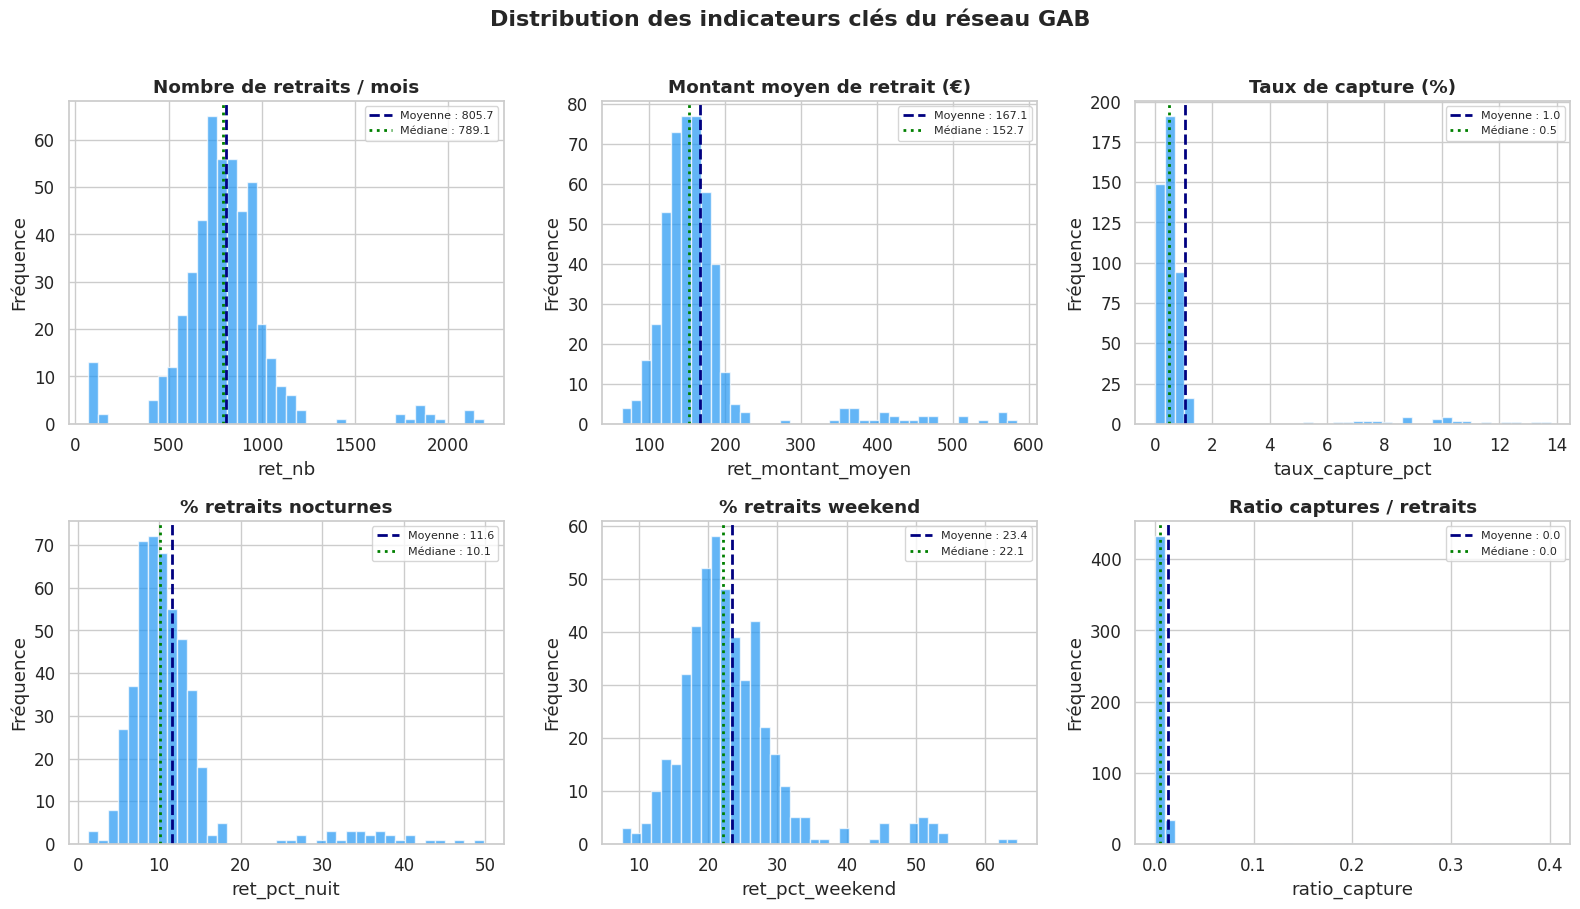

💡 La plupart des GAB se concentrent autour de valeurs stables → c'est le comportement NORMAL.


In [8]:
# ── 5.1 Distributions principales ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution des indicateurs clés du réseau GAB', fontsize=16, fontweight='bold', y=1.01)

variables = [
    ('ret_nb',           'Nombre de retraits / mois'),
    ('ret_montant_moyen','Montant moyen de retrait (€)'),
    ('taux_capture_pct', 'Taux de capture (%)'),
    ('ret_pct_nuit',     '% retraits nocturnes'),
    ('ret_pct_weekend',  '% retraits weekend'),
    ('ratio_capture',    'Ratio captures / retraits'),
]

for ax, (col, titre) in zip(axes.flatten(), variables):
    data_plot = df[col].dropna()
    ax.hist(data_plot, bins=40, color=COULEUR_NORMAL, alpha=0.7, edgecolor='white')
    ax.axvline(data_plot.mean(),   color='navy',  lw=2, ls='--', label=f'Moyenne : {data_plot.mean():.1f}')
    ax.axvline(data_plot.median(), color='green', lw=2, ls=':',  label=f'Médiane : {data_plot.median():.1f}')
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distributions_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 La plupart des GAB se concentrent autour de valeurs stables → c\'est le comportement NORMAL.')

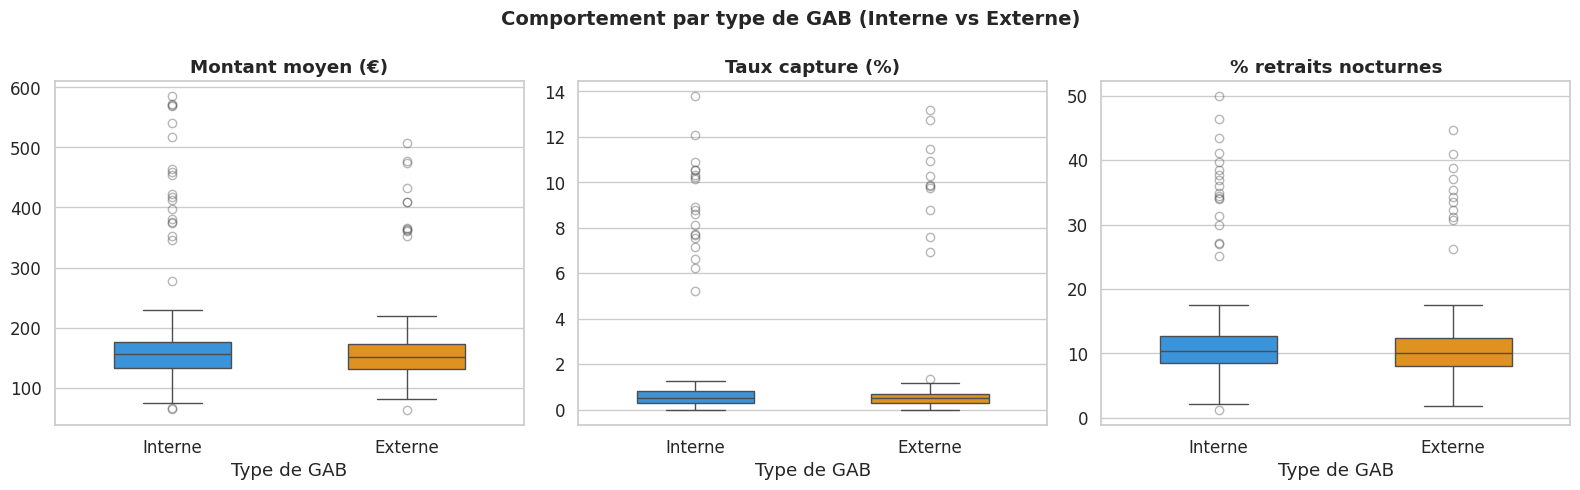

💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.


In [9]:
# ── 5.2 Boxplots par type GAB ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comportement par type de GAB (Interne vs Externe)', fontsize=14, fontweight='bold')

metriques_box = [
    ('ret_montant_moyen', 'Montant moyen (€)'),
    ('taux_capture_pct',  'Taux capture (%)'),
    ('ret_pct_nuit',      '% retraits nocturnes'),
]

for ax, (col, titre) in zip(axes, metriques_box):
    sns.boxplot(data=df, x='type_gab_e_i', y=col, ax=ax,
                palette={'Interne': COULEUR_NORMAL, 'Externe': COULEUR_ACCENT},
                width=0.5, flierprops={'marker':'o','alpha':0.4})
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel('Type de GAB')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('boxplots_type_gab.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les GAB Internes (en agence) ont des profils différents des GAB Externes → à comparer séparément.')

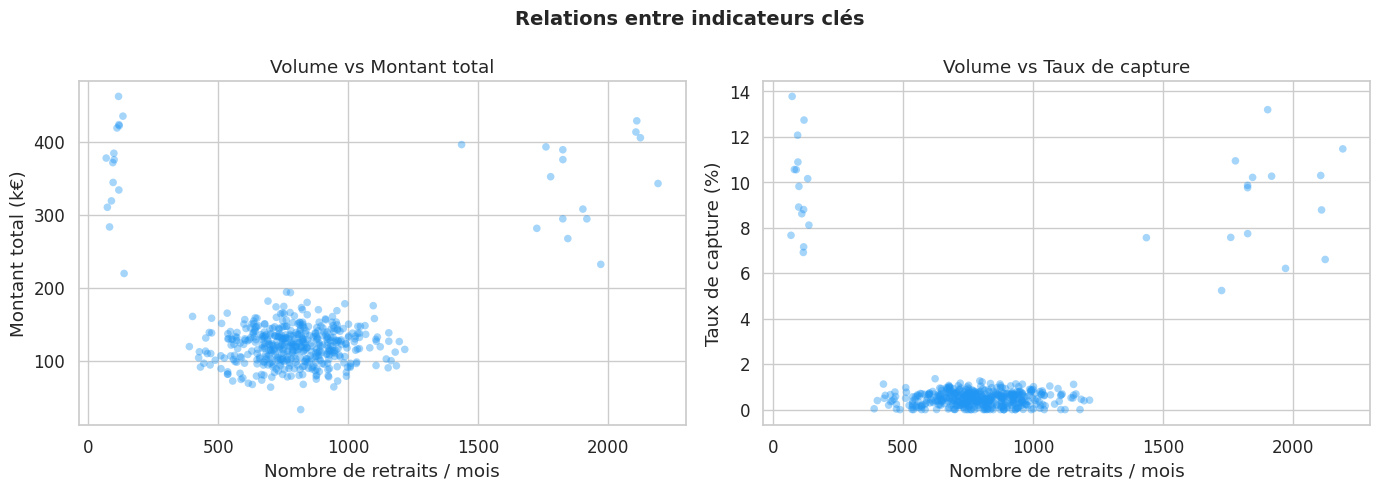

In [10]:
# ── 5.3 Scatter : volume vs montants ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relations entre indicateurs clés', fontsize=14, fontweight='bold')

axes[0].scatter(df['ret_nb'], df['ret_montant_total']/1000,
                alpha=0.4, c=COULEUR_NORMAL, edgecolors='none', s=30)
axes[0].set_xlabel('Nombre de retraits / mois')
axes[0].set_ylabel('Montant total (k€)')
axes[0].set_title('Volume vs Montant total')

axes[1].scatter(df['ret_nb'], df['taux_capture_pct'],
                alpha=0.4, c=COULEUR_NORMAL, edgecolors='none', s=30)
axes[1].set_xlabel('Nombre de retraits / mois')
axes[1].set_ylabel('Taux de capture (%)')
axes[1].set_title('Volume vs Taux de capture')

plt.tight_layout()
plt.savefig('scatter_indicateurs.png', dpi=150, bbox_inches='tight')
plt.show()

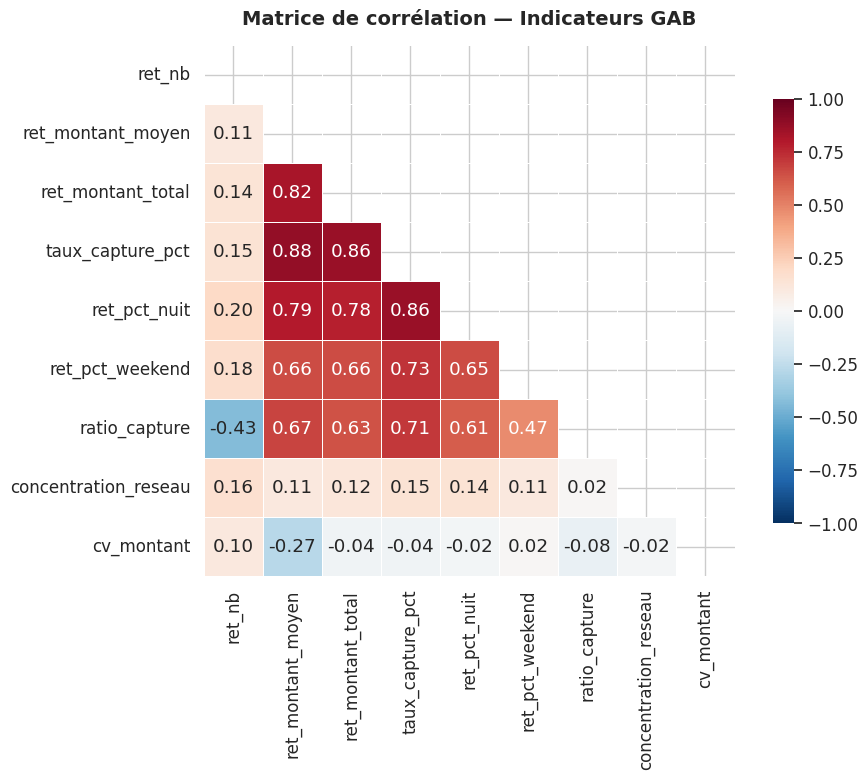

💡 Des corrélations fortes entre variables peuvent indiquer un comportement cohérent (normal) ou anormal.


In [11]:
# ── 5.4 Heatmap de corrélation ─────────────────────────────────────────────────
features_corr = ['ret_nb','ret_montant_moyen','ret_montant_total',
                 'taux_capture_pct','ret_pct_nuit','ret_pct_weekend',
                 'ratio_capture','concentration_reseau','cv_montant']

corr_matrix = df[features_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation — Indicateurs GAB', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Des corrélations fortes entre variables peuvent indiquer un comportement cohérent (normal) ou anormal.')

## 6. 📅 Analyse Temporelle

### Le comportement des GAB évolue-t-il dans le temps ?

La **saisonnalité** est un facteur clé : une hausse d'activité en décembre est normale.  
Ce qui n'est **pas** normal : une hausse isolée sur un seul automate, hors saison.

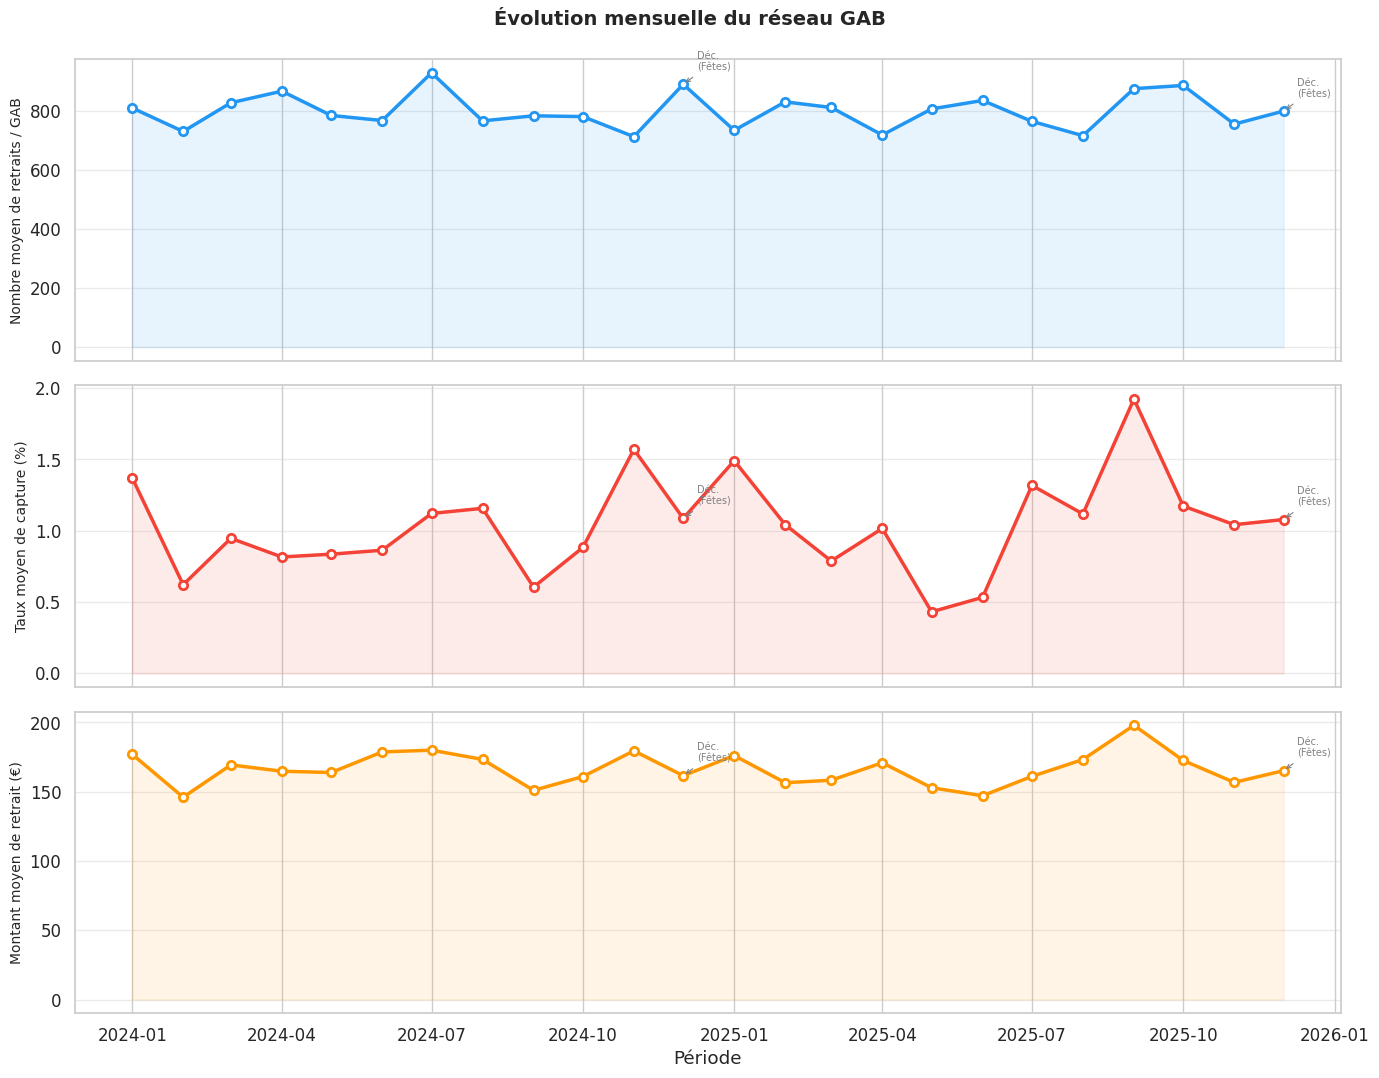

💡 Un pic en décembre est normal. Un pic isolé sur un seul GAB est suspect.


In [12]:
# ── 6.1 Agrégation mensuelle réseau ───────────────────────────────────────────
df_temps = df.groupby(['annee','mois']).agg(
    ret_nb_moyen        = ('ret_nb',            'mean'),
    montant_moyen       = ('ret_montant_moyen',  'mean'),
    taux_capture_moyen  = ('taux_capture_pct',   'mean'),
    pct_nuit_moyen      = ('ret_pct_nuit',       'mean'),
).reset_index()

df_temps['periode'] = pd.to_datetime(
    df_temps['annee'].astype(str) + '-' + df_temps['mois'].astype(str).str.zfill(2)
)
df_temps = df_temps.sort_values('periode')

# ── 6.2 Graphiques temporels ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Évolution mensuelle du réseau GAB', fontsize=14, fontweight='bold')

labels_mois = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

for ax, (col, titre, couleur) in zip(axes, [
    ('ret_nb_moyen',       'Nombre moyen de retraits / GAB',      COULEUR_NORMAL),
    ('taux_capture_moyen', 'Taux moyen de capture (%)',           COULEUR_ANOMALIE),
    ('montant_moyen',      'Montant moyen de retrait (€)',        COULEUR_ACCENT),
]):
    ax.plot(df_temps['periode'], df_temps[col], marker='o', lw=2.5,
            color=couleur, markersize=6, markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(df_temps['periode'], df_temps[col], alpha=0.1, color=couleur)
    ax.set_ylabel(titre, fontsize=10)
    ax.grid(axis='y', alpha=0.4)

    # Annotation décembre (pic naturel)
    dec_rows = df_temps[df_temps['mois'] == 12]
    for _, row in dec_rows.iterrows():
        ax.annotate('Déc.\n(Fêtes)', xy=(row['periode'], row[col]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=7, color='grey',
                    arrowprops={'arrowstyle':'->', 'color':'grey', 'lw':0.8})

axes[-1].set_xlabel('Période')
plt.tight_layout()
plt.savefig('evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Un pic en décembre est normal. Un pic isolé sur un seul GAB est suspect.')

## 6bis. 📅 Vue Annuelle par GAB

### Un GAB atypique ne doit apparaître qu'une seule fois par an

Le problème de l'analyse mensuelle : **le même GAB atypique apparaît plusieurs fois**.  
On crée ici une **table de synthèse annuelle** : 1 ligne par GAB, avec le nombre de mois atypiques  
et la **catégorie de risque**.


In [13]:
# ── Vue annuelle : 1 ligne par GAB (consolidation sur l'année) ────────────────

# Recalcul du flag mensuel si nécessaire
if 'flag_atypique_mois' not in df.columns:
    zscores_cols = [c for c in df.columns if c.startswith('zscore_')]
    if zscores_cols:
        df['nb_metriques_anormales'] = (df[zscores_cols].abs() > 2).sum(axis=1)
    else:
        df['nb_metriques_anormales'] = (
            (df['ret_nb'].sub(df['ret_nb'].mean()).div(df['ret_nb'].std()).abs() > 2).astype(int) +
            (df['taux_capture_pct'].sub(df['taux_capture_pct'].mean()).div(df['taux_capture_pct'].std()).abs() > 2).astype(int) +
            (df['ret_pct_nuit'].sub(df['ret_pct_nuit'].mean()).div(df['ret_pct_nuit'].std()).abs() > 2).astype(int)
        )
    df['flag_atypique_mois'] = (df['nb_metriques_anormales'] >= 2).astype(int)

# Agrégation annuelle
group_cols = ['num_automate'] + (['annee'] if 'annee' in df.columns else [])
df_annuel = df.groupby(group_cols).agg(
    ret_nb_annuel          = ('ret_nb',              'sum'),
    ret_montant_annuel     = ('ret_montant_total',    'sum'),
    ret_montant_moyen_moy  = ('ret_montant_moyen',    'mean'),
    taux_capture_moyen     = ('taux_capture_pct',     'mean'),
    pct_nuit_moyen         = ('ret_pct_nuit',         'mean'),
    pct_weekend_moyen      = ('ret_pct_weekend',      'mean'),
    nb_mois_atypiques      = ('flag_atypique_mois',   'sum'),
    nb_mois_actifs         = ('flag_atypique_mois',   'count'),
    **({'type_gab_e_i': ('type_gab_e_i', 'first')} if 'type_gab_e_i' in df.columns else {}),
    **({'code_postal':  ('code_postal',  'first')} if 'code_postal'  in df.columns else {}),
    **({'longitude':    ('longitude',    'first')} if 'longitude'    in df.columns else {}),
    **({'latitude':     ('latitude',     'first')} if 'latitude'     in df.columns else {}),
).reset_index()

df_annuel['pct_mois_atypiques'] = (df_annuel['nb_mois_atypiques'] / df_annuel['nb_mois_actifs'] * 100).round(1)

df_annuel['categorie_risque'] = pd.cut(
    df_annuel['nb_mois_atypiques'],
    bins=[-1, 0, 2, 5, 100],
    labels=['🟢 Normal', '🟡 Modéré (1-2 mois)', '🟠 Élevé (3-5 mois)', '🔴 Critique (6+ mois)']
)

nb_atypiques_annuel = (df_annuel['nb_mois_atypiques'] > 0).sum()
print(f'📋 Vue annuelle : {len(df_annuel)} GAB distincts')
print(f'   🔴 GAB avec au moins 1 mois atypique : {nb_atypiques_annuel}')
print(f'   🟢 GAB sans aucun mois atypique       : {len(df_annuel) - nb_atypiques_annuel}')
print()
print(df_annuel['categorie_risque'].value_counts().sort_index().to_string())


📋 Vue annuelle : 480 GAB distincts
   🔴 GAB avec au moins 1 mois atypique : 30
   🟢 GAB sans aucun mois atypique       : 450

categorie_risque
🟢 Normal                450
🟡 Modéré (1-2 mois)      30
🟠 Élevé (3-5 mois)        0
🔴 Critique (6+ mois)      0


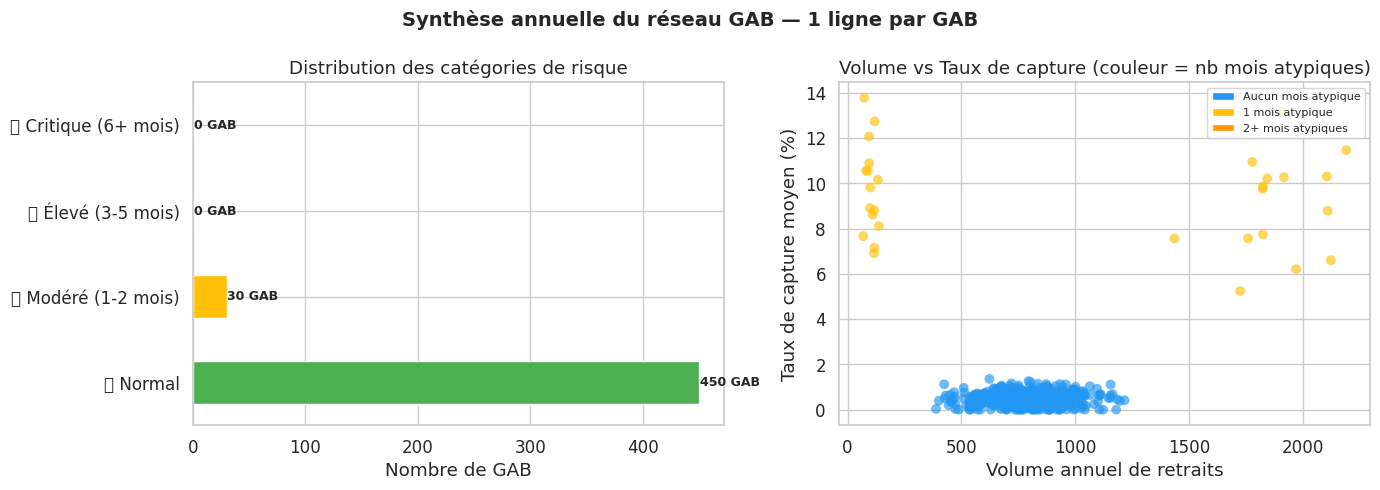


🏆 Top 10 GAB les plus à risque (vue annuelle) :


,num_automate,nb_mois_atypiques,nb_mois_actifs,pct_mois_atypiques,categorie_risque,taux_capture_moyen,pct_nuit_moyen
1,GAB_ANOM_000,1,1,100.000000,🟡 Modéré (1-2 mois),6.606204,26.999803
2,GAB_ANOM_001,1,1,100.000000,🟡 Modéré (1-2 mois),10.270981,38.706393
3,GAB_ANOM_002,1,1,100.000000,🟡 Modéré (1-2 mois),5.239910,34.854533
4,GAB_ANOM_003,1,1,100.000000,🟡 Modéré (1-2 mois),7.565840,36.963010
5,GAB_ANOM_004,1,1,100.000000,🟡 Modéré (1-2 mois),8.785691,40.905292
6,GAB_ANOM_005,1,1,100.000000,🟡 Modéré (1-2 mois),9.822548,33.519257
7,GAB_ANOM_006,1,1,100.000000,🟡 Modéré (1-2 mois),10.556620,49.868871
8,GAB_ANOM_007,1,1,100.000000,🟡 Modéré (1-2 mois),10.946632,37.119892
9,GAB_ANOM_008,1,1,100.000000,🟡 Modéré (1-2 mois),7.743815,31.396851
10,GAB_ANOM_009,1,1,100.000000,🟡 Modéré (1-2 mois),10.893783,39.716634


In [14]:
# ── Visualisation de la vue annuelle ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthèse annuelle du réseau GAB — 1 ligne par GAB', fontsize=14, fontweight='bold')

# Graphique 1 : distribution des catégories de risque
ax1 = axes[0]
cat_counts = df_annuel['categorie_risque'].value_counts().sort_index()
bar_colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336'][:len(cat_counts)]
cat_counts.plot(kind='barh', ax=ax1, color=bar_colors, edgecolor='white')
ax1.set_title('Distribution des catégories de risque')
ax1.set_xlabel('Nombre de GAB')
ax1.set_ylabel('')
for bar, val in zip(ax1.patches, cat_counts.values):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val} GAB', va='center', fontsize=9, fontweight='bold')

# Graphique 2 : scatter volume vs taux capture, coloré par risque
ax2 = axes[1]
color_map = {0: COULEUR_NORMAL, 1: '#FFC107', 2: COULEUR_ACCENT}
c_scatter = df_annuel['nb_mois_atypiques'].clip(0, 2).map(color_map)
sc = ax2.scatter(df_annuel['ret_nb_annuel'], df_annuel['taux_capture_moyen'],
                 c=c_scatter, alpha=0.65, s=50, edgecolors='none')
ax2.set_xlabel('Volume annuel de retraits')
ax2.set_ylabel('Taux de capture moyen (%)')
ax2.set_title('Volume vs Taux de capture (couleur = nb mois atypiques)')
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(facecolor=COULEUR_NORMAL, label='Aucun mois atypique'),
    Patch(facecolor='#FFC107',      label='1 mois atypique'),
    Patch(facecolor=COULEUR_ACCENT, label='2+ mois atypiques'),
], loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Top 10 GAB à risque
top_annuel = df_annuel.nlargest(10, 'nb_mois_atypiques')[
    ['num_automate', 'nb_mois_atypiques', 'nb_mois_actifs',
     'pct_mois_atypiques', 'categorie_risque', 'taux_capture_moyen', 'pct_nuit_moyen']
].reset_index(drop=True)
top_annuel.index += 1
print('\n🏆 Top 10 GAB les plus à risque (vue annuelle) :')
display(top_annuel.style.background_gradient(subset=['nb_mois_atypiques','pct_mois_atypiques'], cmap='YlOrRd'))


## 7. 🗺️ Analyse Géographique

La localisation d'un GAB influence fortement son comportement.  
Un GAB en centre-ville traite naturellement plus de retraits qu'un GAB rural.  
La carte nous permet de **contextualiser** chaque anomalie géographiquement.

In [15]:
# ── 7.1 Carte interactive Plotly ──────────────────────────────────────────────
df_geo = df.groupby('num_automate').agg(
    longitude          = ('longitude',        'first'),
    latitude           = ('latitude',         'first'),
    ret_nb_moyen       = ('ret_nb',            'mean'),
    taux_capture_moyen = ('taux_capture_pct',  'mean'),
    type_gab           = ('type_gab_e_i',      'first'),
    code_postal        = ('code_postal',       'first'),
).reset_index()

fig_map = px.scatter_mapbox(
    df_geo,
    lat='latitude', lon='longitude',
    color='taux_capture_moyen',
    size='ret_nb_moyen',
    size_max=20,
    color_continuous_scale=['#2196F3', '#FF9800', '#F44336'],
    hover_name='num_automate',
    hover_data={'taux_capture_moyen': ':.2f', 'ret_nb_moyen': ':.0f', 'type_gab': True},
    zoom=5,
    center={'lat': 46.8, 'lon': 2.3},
    mapbox_style='carto-positron',
    title='🗺️ Réseau GAB — Intensité de retrait et taux de capture',
    labels={'taux_capture_moyen': 'Taux capture (%)', 'ret_nb_moyen': 'Nb retraits moyen'},
    height=550
)
fig_map.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig_map.show()
print('💡 Les points rouges (taux de capture élevé) méritent une attention particulière.')

💡 Les points rouges (taux de capture élevé) méritent une attention particulière.


## 8. 🤖 Modélisation — Détection d'Anomalies

### Pourquoi l'Isolation Forest ?

| Modèle | Principe | Adapté ici ? |
|---|---|---|
| **Isolation Forest** | Isole les points rares par partitions aléatoires | ✅ Oui — rapide, robuste, interprétable |
| Local Outlier Factor | Densité locale vs voisins | ⚠️ Lent sur grands datasets |
| One-Class SVM | Frontière autour des normaux | ⚠️ Difficile à paramétrer |
| Seuils statistiques | z-score, IQR | ⚠️ Univarié, ne capte pas les interactions |

**Isolation Forest** est notre choix car :
- Il gère bien les **données multivariées** (50+ colonnes)
- Il est **rapide** sur de grands volumes
- Il produit un **score d'anomalie** continu (pas seulement un label)
- Il est **intuitif** : un point difficile à isoler = normal, facile à isoler = anormal

In [16]:
# ── 8.1 Sélection des features pour le modèle ─────────────────────────────────
FEATURES_MODELE = [
    'ret_nb',
    'ret_montant_moyen',
    'ret_montant_max',
    'ret_montant_stddev',
    'ret_montant_total',
    'taux_capture_pct',
    'ret_pct_nuit',
    'ret_pct_weekend',
    'intensite_retrait',
    'ratio_capture',
    'concentration_reseau',
    'score_horaires_atypiques',
    'cv_montant',
    'nb_ope_reseau_Franfinance',
    'nb_ope_reseau_CB',
    'nb_ope_reseau_Trionis',
    'nb_ope_reseau_PPL',
    'nb_ope_reseau_Mastercard',
    'nb_ope_reseau_Configona',
    'nb_ope_reseau_Interne',
    'nb_ope_reseau_Casino',
    'nb_ope_reseau_Accord',
    'nb_ope_reseau_Visa',
    'nb_ope_reseau_COS',
    'nb_ope_reseau_JCB',
    'nb_ope_reseau_PostEpargne',
    'nb_ope_reseau_Diners_et_Discovery',
    'nb_ope_reseau_autres',
]

X = df[FEATURES_MODELE].fillna(0)

# ── 8.2 Normalisation ─────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Matrice features : {X_scaled.shape[0]} lignes × {X_scaled.shape[1]} colonnes')

✅ Matrice features : 480 lignes × 28 colonnes


In [17]:
# ── 8.3 Entraînement Isolation Forest ─────────────────────────────────────────
# contamination = proportion estimée d'anomalies dans le réseau (~5%)
modele = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

df['score_anomalie'] = modele.fit_predict(X_scaled)  # -1 = anomalie, +1 = normal
df['score_if']       = modele.score_samples(X_scaled)  # plus bas = plus anormal

# Normalisation du score en [0, 1] pour lisibilité métier
score_min, score_max = df['score_if'].min(), df['score_if'].max()
df['score_risque'] = 1 - (df['score_if'] - score_min) / (score_max - score_min)
# score_risque proche de 1 = très anormal

df['est_anomalie'] = (df['score_anomalie'] == -1).astype(int)

n_anomalies = df['est_anomalie'].sum()
print(f'🚨 GAB atypiques détectés : {n_anomalies} / {len(df)} ({n_anomalies/len(df)*100:.1f}%)')

🚨 GAB atypiques détectés : 24 / 480 (5.0%)


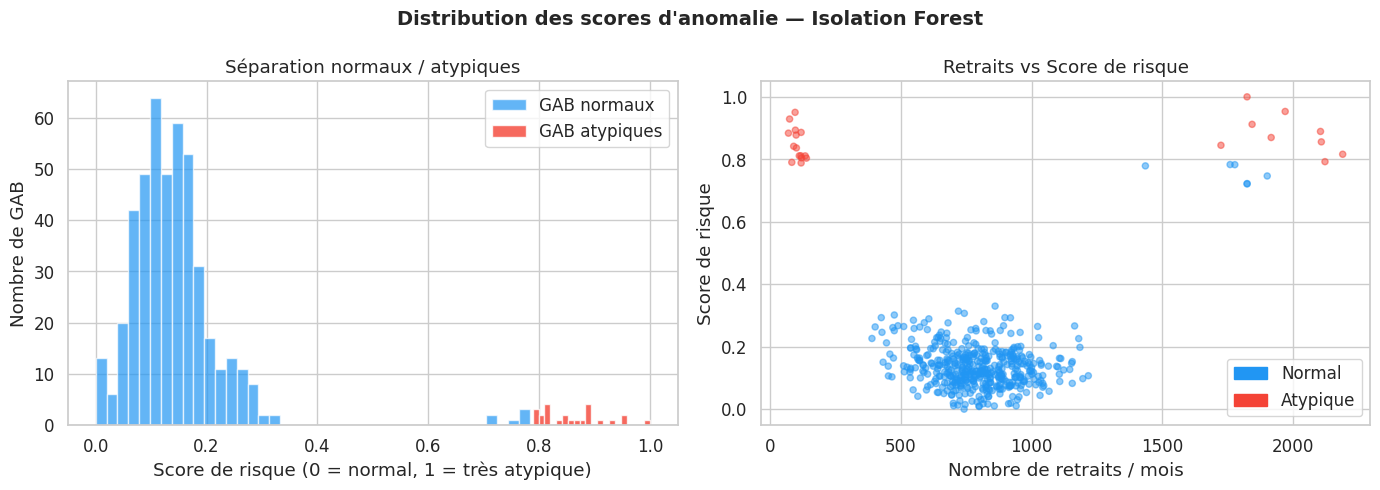

In [18]:
# ── 8.4 Visualisation du score d'anomalie ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des scores d\'anomalie — Isolation Forest', fontsize=14, fontweight='bold')

# Histogramme des scores
ax = axes[0]
ax.hist(df[df['est_anomalie']==0]['score_risque'], bins=40,
        color=COULEUR_NORMAL, alpha=0.7, label='GAB normaux')
ax.hist(df[df['est_anomalie']==1]['score_risque'], bins=20,
        color=COULEUR_ANOMALIE, alpha=0.8, label='GAB atypiques')
ax.set_xlabel('Score de risque (0 = normal, 1 = très atypique)')
ax.set_ylabel('Nombre de GAB')
ax.set_title('Séparation normaux / atypiques')
ax.legend()

# Scatter retraits vs score risque
ax2 = axes[1]
couleurs = [COULEUR_ANOMALIE if a==1 else COULEUR_NORMAL for a in df['est_anomalie']]
ax2.scatter(df['ret_nb'], df['score_risque'], c=couleurs, alpha=0.5, s=20)
ax2.set_xlabel('Nombre de retraits / mois')
ax2.set_ylabel('Score de risque')
ax2.set_title('Retraits vs Score de risque')
patch_n = mpatches.Patch(color=COULEUR_NORMAL,   label='Normal')
patch_a = mpatches.Patch(color=COULEUR_ANOMALIE, label='Atypique')
ax2.legend(handles=[patch_n, patch_a])

plt.tight_layout()
plt.savefig('scores_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 🔎 Explication des Anomalies Détectées

### Pourquoi ces GAB sont-ils atypiques ?

C'est **la partie la plus importante** pour convaincre les experts métier.  
Chaque anomalie doit être **expliquée en langage métier**.

In [19]:
# ── 9.1 Top 10 GAB les plus atypiques ─────────────────────────────────────────
top_anomalies = df[df['est_anomalie']==1].nlargest(10, 'score_risque')[
    ['num_automate','score_risque','ret_nb','ret_montant_moyen',
     'taux_capture_pct','ret_pct_nuit','ret_pct_weekend','type_gab_e_i']
].reset_index(drop=True)

top_anomalies.index += 1
top_anomalies.columns = ['Automate','Score risque','Nb retraits',
                          'Montant moyen (€)','Taux capture (%)','% Nuit','% Weekend','Type']

# Formatage
styled = top_anomalies.style \
    .background_gradient(subset=['Score risque'], cmap='Reds') \
    .background_gradient(subset=['Taux capture (%)'], cmap='Oranges') \
    .format({'Score risque': '{:.3f}', 'Taux capture (%)': '{:.2f}',
             'Montant moyen (€)': '{:.0f}', '% Nuit': '{:.1f}', '% Weekend': '{:.1f}'})

print('🚨 TOP 10 des GAB les plus atypiques :')
display(styled)

🚨 TOP 10 des GAB les plus atypiques :


,Automate,Score risque,Nb retraits,Montant moyen (€),Taux capture (%),% Nuit,% Weekend,Type
1,GAB_ANOM_028,1.000,1825.653488,353,9.87,44.6,62.5,Externe
2,GAB_ANOM_018,0.953,1971.647210,374,6.21,46.3,64.6,Interne
3,GAB_ANOM_020,0.950,94.408472,572,12.08,41.1,39.2,Interne
4,GAB_ANOM_017,0.929,73.325165,541,13.78,37.6,50.6,Interne
5,GAB_ANOM_025,0.912,1844.885306,572,10.22,38.4,54.4,Interne
6,GAB_ANOM_009,0.893,95.516203,518,10.89,39.7,51.2,Interne
7,GAB_ANOM_011,0.889,2106.931306,569,10.30,35.9,26.7,Interne
8,GAB_ANOM_022,0.886,117.552423,459,7.16,17.6,50.4,Interne
9,GAB_ANOM_024,0.884,68.914708,454,7.67,34.5,34.0,Interne
10,GAB_ANOM_016,0.878,98.383829,418,8.91,34.0,45.2,Interne


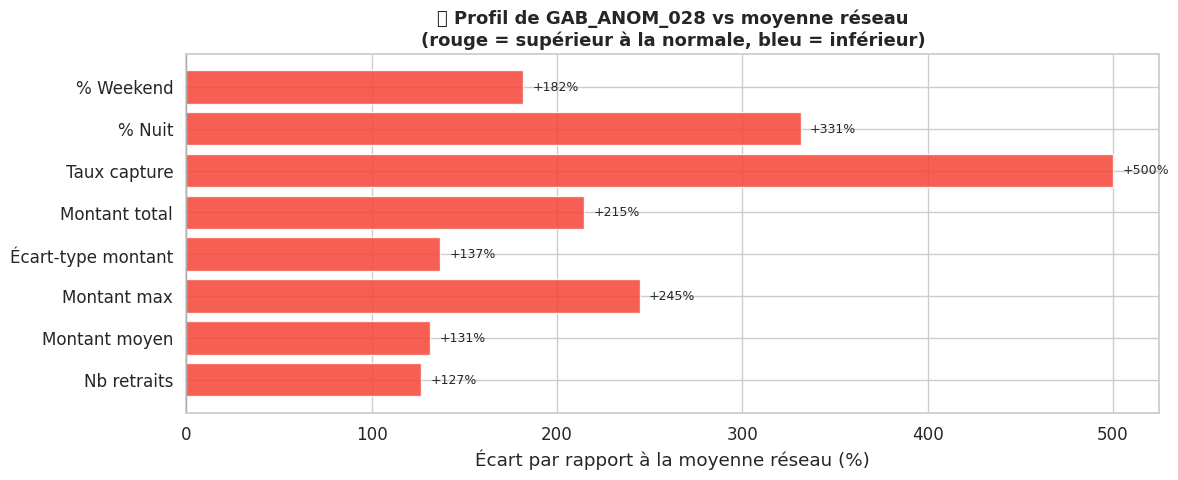


📋 Interprétation métier de GAB_ANOM_028 :
   → Taux de capture : 9.9%  (réseau : 0.6%)
   → Montant moyen   : 353€  (réseau : 153€)
   → Activité nocturne : 44.6%  (réseau : 10.3%)


In [20]:
# ── 9.2 Profil d'un GAB atypique vs le réseau ─────────────────────────────────
# Sélection du GAB le plus atypique
gab_anomalie = df[df['est_anomalie']==1].nlargest(1, 'score_risque').iloc[0]
gab_id = gab_anomalie['num_automate']

# Moyennes réseau (normaux)
moyennes_normaux = df[df['est_anomalie']==0][FEATURES_MODELE[:8]].mean()
valeurs_anomalie = df[df['num_automate']==gab_id][FEATURES_MODELE[:8]].mean()

# Calcul des écarts en % par rapport à la moyenne
ecarts = ((valeurs_anomalie - moyennes_normaux) / moyennes_normaux * 100).clip(-200, 500)

labels_fr = {
    'ret_nb'             : 'Nb retraits',
    'ret_montant_moyen'  : 'Montant moyen',
    'ret_montant_max'    : 'Montant max',
    'ret_montant_stddev' : 'Écart-type montant',
    'ret_montant_total'  : 'Montant total',
    'taux_capture_pct'   : 'Taux capture',
    'ret_pct_nuit'       : '% Nuit',
    'ret_pct_weekend'    : '% Weekend',
}

fig, ax = plt.subplots(figsize=(12, 5))
couleurs_barres = [COULEUR_ANOMALIE if v > 0 else COULEUR_NORMAL for v in ecarts.values]
bars = ax.barh([labels_fr.get(c, c) for c in ecarts.index], ecarts.values,
               color=couleurs_barres, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('Écart par rapport à la moyenne réseau (%)')
ax.set_title(f'🔍 Profil de {gab_id} vs moyenne réseau\n(rouge = supérieur à la normale, bleu = inférieur)',
             fontsize=13, fontweight='bold')

# Annotations valeur absolue
for bar, val in zip(bars, ecarts.values):
    x = bar.get_width()
    ax.text(x + (5 if x >= 0 else -5), bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('profil_anomalie.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📋 Interprétation métier de {gab_id} :')
print(f'   → Taux de capture : {gab_anomalie["taux_capture_pct"]:.1f}%  (réseau : {moyennes_normaux["taux_capture_pct"]:.1f}%)')
print(f'   → Montant moyen   : {gab_anomalie["ret_montant_moyen"]:.0f}€  (réseau : {moyennes_normaux["ret_montant_moyen"]:.0f}€)')
print(f'   → Activité nocturne : {gab_anomalie["ret_pct_nuit"]:.1f}%  (réseau : {moyennes_normaux["ret_pct_nuit"]:.1f}%)')

In [21]:
# ── 9.3 Radar chart : comparaison GAB atypique vs réseau ──────────────────────
categories = ['Nb retraits', 'Montant moyen', 'Taux capture',
              '% Nuit', '% Weekend', 'Ratio capture']
cols_radar  = ['ret_nb','ret_montant_moyen','taux_capture_pct',
               'ret_pct_nuit','ret_pct_weekend','ratio_capture']

# Normalisation min-max pour le radar
def normaliser_radar(valeurs, ref_min, ref_max):
    return [(v - mn) / (mx - mn + 1e-9) for v, mn, mx in zip(valeurs, ref_min, ref_max)]

ref_min = df[cols_radar].quantile(0.05).values
ref_max = df[cols_radar].quantile(0.95).values

vals_anomalie = normaliser_radar(df[df['num_automate']==gab_id][cols_radar].mean().values, ref_min, ref_max)
vals_normal   = normaliser_radar(df[df['est_anomalie']==0][cols_radar].mean().values, ref_min, ref_max)

fig_radar = go.Figure()
for vals, nom, couleur in [
    (vals_anomalie, f'{gab_id} (Atypique)', COULEUR_ANOMALIE),
    (vals_normal,   'Moyenne réseau (Normal)', COULEUR_NORMAL),
]:
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=categories + [categories[0]],
        fill='toself',
        name=nom,
        line_color=couleur,
        fillcolor=couleur,
        opacity=0.35
    ))

fig_radar.update_layout(
    polar={'radialaxis': {'visible': True, 'range': [0, 1]}},
    title=f'Radar — {gab_id} vs Moyenne réseau',
    height=500
)
fig_radar.show()
print('💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.')

💡 Le GAB atypique dépasse significativement la zone normale sur plusieurs axes simultanément.


In [22]:
# ── 9.4 Carte des anomalies détectées ─────────────────────────────────────────
df_geo2 = df.groupby('num_automate').agg(
    longitude     = ('longitude',    'first'),
    latitude      = ('latitude',     'first'),
    score_risque  = ('score_risque', 'mean'),
    est_anomalie  = ('est_anomalie', 'max'),
    ret_nb_moyen  = ('ret_nb',       'mean'),
    taux_capture  = ('taux_capture_pct','mean'),
).reset_index()

df_geo2['statut'] = df_geo2['est_anomalie'].map({0: 'Normal', 1: 'Atypique'})

fig_anom_map = px.scatter_mapbox(
    df_geo2,
    lat='latitude', lon='longitude',
    color='statut',
    color_discrete_map={'Normal': COULEUR_NORMAL, 'Atypique': COULEUR_ANOMALIE},
    size='score_risque',
    size_max=18,
    hover_name='num_automate',
    hover_data={'taux_capture': ':.2f', 'ret_nb_moyen': ':.0f', 'score_risque': ':.3f'},
    zoom=5,
    center={'lat': 46.8, 'lon': 2.3},
    mapbox_style='carto-positron',
    title='🗺️ GAB Normaux vs Atypiques — Vue géographique',
    height=550
)
fig_anom_map.update_layout(margin={'r':0,'t':50,'l':0,'b':0})
fig_anom_map.show()

### 9.5 🏷️ Raison principale de l'atypisme

Pour chaque GAB détecté, on génère une **explication lisible** en langage métier :  
quel est le signal principal qui déclenche l'alerte ?


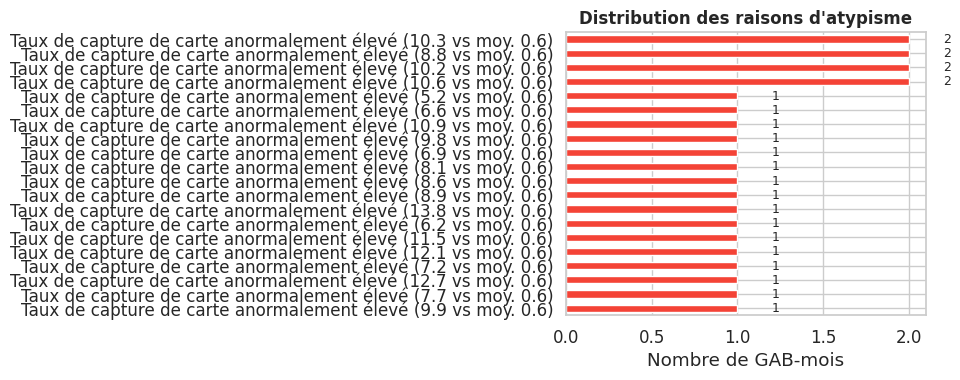

🏧 Top 15 GAB atypiques avec raison d'alerte :


,num_automate,score_risque,raison_principale,detail_atypisme
1,GAB_ANOM_028,1.000000,Taux de capture de carte anormalement élevé (9.9 vs moy. 0.6),Taux de capture de carte anormalement élevé (9.9 vs moy. 0.6) | Activité nocturne anormalement élevée (44.6 vs moy. 10.3) | Activité weekend anormalement élevée (62.5 vs moy. 22.2)
2,GAB_ANOM_018,0.953210,Taux de capture de carte anormalement élevé (6.2 vs moy. 0.6),Taux de capture de carte anormalement élevé (6.2 vs moy. 0.6) | Activité nocturne anormalement élevée (46.3 vs moy. 10.3) | Activité weekend anormalement élevée (64.6 vs moy. 22.2)
3,GAB_ANOM_020,0.950434,Taux de capture de carte anormalement élevé (12.1 vs moy. 0.6),Taux de capture de carte anormalement élevé (12.1 vs moy. 0.6) | Activité nocturne anormalement élevée (41.1 vs moy. 10.3) | Activité weekend anormalement élevée (39.2 vs moy. 22.2)
4,GAB_ANOM_017,0.929001,Taux de capture de carte anormalement élevé (13.8 vs moy. 0.6),Taux de capture de carte anormalement élevé (13.8 vs moy. 0.6) | Activité nocturne anormalement élevée (37.6 vs moy. 10.3) | Activité weekend anormalement élevée (50.6 vs moy. 22.2)
5,GAB_ANOM_025,0.912029,Taux de capture de carte anormalement élevé (10.2 vs moy. 0.6),Taux de capture de carte anormalement élevé (10.2 vs moy. 0.6) | Activité nocturne anormalement élevée (38.4 vs moy. 10.3) | Activité weekend anormalement élevée (54.4 vs moy. 22.2)
6,GAB_ANOM_009,0.893448,Taux de capture de carte anormalement élevé (10.9 vs moy. 0.6),Taux de capture de carte anormalement élevé (10.9 vs moy. 0.6) | Activité nocturne anormalement élevée (39.7 vs moy. 10.3) | Activité weekend anormalement élevée (51.2 vs moy. 22.2)
7,GAB_ANOM_011,0.889221,Taux de capture de carte anormalement élevé (10.3 vs moy. 0.6),Taux de capture de carte anormalement élevé (10.3 vs moy. 0.6) | Activité nocturne anormalement élevée (35.9 vs moy. 10.3) | Montant moyen de retrait anormalement élevé (568.8 vs moy. 152.6)
8,GAB_ANOM_022,0.886173,Taux de capture de carte anormalement élevé (7.2 vs moy. 0.6),Taux de capture de carte anormalement élevé (7.2 vs moy. 0.6) | Activité nocturne anormalement élevée (17.6 vs moy. 10.3) | Activité weekend anormalement élevée (50.4 vs moy. 22.2)
9,GAB_ANOM_024,0.883820,Taux de capture de carte anormalement élevé (7.7 vs moy. 0.6),Taux de capture de carte anormalement élevé (7.7 vs moy. 0.6) | Activité nocturne anormalement élevée (34.5 vs moy. 10.3) | Activité weekend anormalement élevée (34.0 vs moy. 22.2)
10,GAB_ANOM_016,0.877677,Taux de capture de carte anormalement élevé (8.9 vs moy. 0.6),Taux de capture de carte anormalement élevé (8.9 vs moy. 0.6) | Activité nocturne anormalement élevée (34.0 vs moy. 10.3) | Activité weekend anormalement élevée (45.2 vs moy. 22.2)


In [23]:
# ── 9.5 Explication métier des anomalies ──────────────────────────────────────

def generer_raison(row, moy_ref):
    """Retourne (raison_principale, detail) pour un GAB atypique."""
    signaux = []
    checks = [
        ('taux_capture_pct',  'Taux de capture de carte anormalement élevé',    True),
        ('ret_pct_nuit',      'Activité nocturne anormalement élevée',           True),
        ('ret_pct_weekend',   'Activité weekend anormalement élevée',            True),
        ('ret_montant_moyen', 'Montant moyen de retrait anormalement élevé',     True),
        ('ret_montant_moyen', 'Montant moyen de retrait anormalement bas',       False),
        ('ret_nb',            'Volume de retraits anormalement élevé',           True),
        ('ret_nb',            'Volume de retraits anormalement bas (panne ?)',   False),
    ]
    for col, label, positif in checks:
        if col not in row.index or col not in moy_ref.index:
            continue
        moy = moy_ref[col]
        if moy == 0:
            continue
        ecart_relatif = (row[col] - moy) / moy
        seuil = 0.5  # +/- 50% par rapport à la moyenne réseau
        if positif  and ecart_relatif >  seuil:
            signaux.append(f'{label} ({row[col]:.1f} vs moy. {moy:.1f})')
        elif not positif and ecart_relatif < -seuil:
            signaux.append(f'{label} ({row[col]:.1f} vs moy. {moy:.1f})')

    if not signaux:
        signaux.append('Combinaison de signaux faibles sur plusieurs métriques')

    return signaux[0], ' | '.join(signaux[:3])

# Références : moyennes sur les GAB normaux
moy_ref = df[df['est_anomalie']==0][
    ['taux_capture_pct','ret_pct_nuit','ret_pct_weekend','ret_montant_moyen','ret_nb']
].mean()

anom = df[df['est_anomalie']==1].copy()
res  = anom.apply(lambda r: generer_raison(r, moy_ref), axis=1)
anom['raison_principale'] = [r[0] for r in res]
anom['detail_atypisme']   = [r[1] for r in res]
# Stocker dans df principal
df.loc[df['est_anomalie']==1, 'raison_principale'] = anom['raison_principale'].values
df.loc[df['est_anomalie']==1, 'detail_atypisme']   = anom['detail_atypisme'].values

# ── Distribution des raisons ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
counts  = anom['raison_principale'].value_counts()
colors  = [COULEUR_ANOMALIE if 'capture' in r.lower() else
           COULEUR_ACCENT   if 'nocturn' in r.lower() or 'weekend' in r.lower() else
           '#9C27B0' for r in counts.index]
counts.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Distribution des raisons d\'atypisme', fontsize=12, fontweight='bold')
ax.set_xlabel('Nombre de GAB-mois')
ax.set_ylabel('')
ax.invert_yaxis()
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout(); plt.show()

# ── Table enrichie avec raisons ──────────────────────────────────────────────
cols_show = ['num_automate', 'score_risque', 'raison_principale', 'detail_atypisme']
if 'cluster_nom' in anom.columns:
    cols_show.insert(2, 'cluster_nom')
cols_show = [c for c in cols_show if c in anom.columns]

top_enrichi = anom.nlargest(15, 'score_risque')[cols_show].reset_index(drop=True)
top_enrichi.index += 1
print('🏧 Top 15 GAB atypiques avec raison d\'alerte :')
display(top_enrichi.style.background_gradient(subset=['score_risque'], cmap='Reds'))


## 9bis. 🔬 Clustering — Familles de comportements GAB

### Regrouper les GAB par profil similaire permet une comparaison équitable

Plutôt que de comparer tous les GAB entre eux, le clustering identifie des **familles de comportements** :
les GAB sont comparés à leurs **pairs** plutôt qu'au réseau entier.  
Un GAB rural et un GAB de centre commercial ne sont pas "normaux" de la même façon.


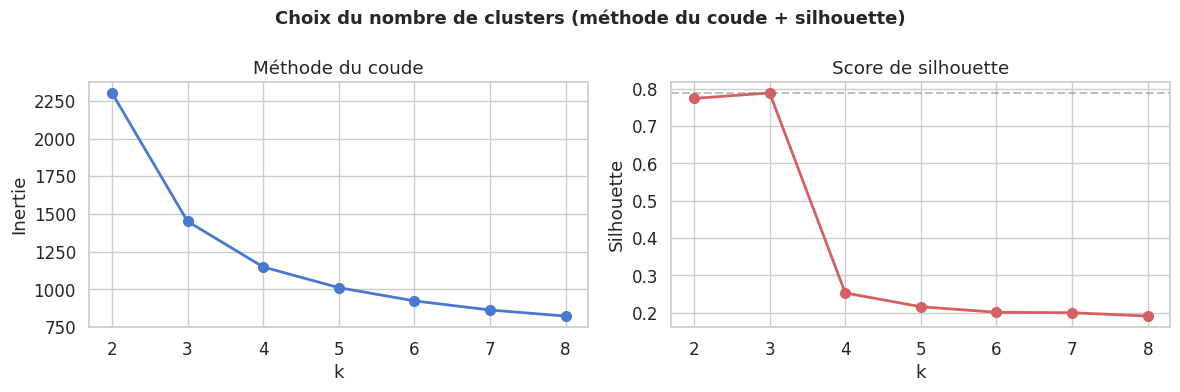

✅ k optimal : 3 clusters (silhouette = 0.789)


In [24]:
# ── Clustering KMeans — recherche du k optimal ───────────────────────────────
FEATURES_CLUSTER = [
    'ret_nb', 'ret_montant_moyen', 'ret_montant_max',
    'ret_pct_nuit', 'ret_pct_weekend', 'taux_capture_pct',
    'intensite_retrait', 'ratio_capture', 'cv_montant', 'score_horaires_atypiques',
]
FEATURES_CLUSTER = [f for f in FEATURES_CLUSTER if f in df.columns]

X_clust = StandardScaler().fit_transform(df[FEATURES_CLUSTER].fillna(0))

inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Choix du nombre de clusters (méthode du coude + silhouette)', fontsize=13, fontweight='bold')
axes[0].plot(K_range, inertias,   'bo-', lw=2, ms=7); axes[0].set_title('Méthode du coude');     axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie')
axes[1].plot(K_range, sil_scores, 'ro-', lw=2, ms=7); axes[1].set_title('Score de silhouette'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].axhline(max(sil_scores), color='gray', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

k_optimal = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'✅ k optimal : {k_optimal} clusters (silhouette = {max(sil_scores):.3f})')


In [25]:
# ── Entraînement KMeans final ─────────────────────────────────────────────────
K_FINAL = k_optimal  # Ajuster si nécessaire

scaler_clust = StandardScaler()
X_clust_sc   = scaler_clust.fit_transform(df[FEATURES_CLUSTER].fillna(0))
km_final     = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_clust_sc)

# Profil moyen des clusters
profil = df.groupby('cluster')[FEATURES_CLUSTER + ['est_anomalie']].mean().round(2)
print('📊 Profil moyen par cluster :')
display(profil.style.background_gradient(cmap='YlOrRd'))

# Nommage heuristique
def nommer_cluster(idx, row):
    if row['est_anomalie'] > 0.15:                    return f'🔴 Cluster {idx} — Atypiques à risque'
    if 'ret_pct_nuit' in row and row['ret_pct_nuit'] > 18:   return f'🌙 Cluster {idx} — Activité nocturne'
    if 'taux_capture_pct' in row and row['taux_capture_pct'] > 1.5: return f'🃏 Cluster {idx} — Captures fréquentes'
    if 'ret_nb' in row and row['ret_nb'] > 900:       return f'🏙️ Cluster {idx} — Fort volume (urbain)'
    return f'🟢 Cluster {idx} — Comportement standard'

noms = {i: nommer_cluster(i, profil.iloc[i]) for i in range(K_FINAL)}
df['cluster_nom'] = df['cluster'].map(noms)

print('\n📋 Répartition des clusters :')
dist = df.groupby(['cluster','cluster_nom'])['est_anomalie'].agg(['count','mean']).reset_index()
dist.columns = ['Cluster','Profil','Nb GAB-mois','% Anomalies']
dist['% Anomalies'] = (dist['% Anomalies'] * 100).round(1)
print(dist.to_string(index=False))


📊 Profil moyen par cluster :


,ret_nb,ret_montant_moyen,ret_montant_max,ret_pct_nuit,ret_pct_weekend,taux_capture_pct,intensite_retrait,ratio_capture,cv_montant,score_horaires_atypiques,est_anomalie
cluster,,,,,,,,,,,
0,792.920000,149.370000,496.900000,10.030000,21.840000,0.480000,26.430000,0.010000,0.420000,2.000000,0.000000
1,103.510000,452.610000,1189.980000,33.930000,45.380000,9.790000,3.450000,0.260000,0.350000,5.460000,1.000000
2,1889.940000,414.300000,1203.570000,36.040000,47.940000,9.050000,63.000000,0.010000,0.450000,5.780000,0.600000



📋 Répartition des clusters :
 Cluster                              Profil  Nb GAB-mois  % Anomalies
       0 🟢 Cluster 0 — Comportement standard          450          0.0
       1    🔴 Cluster 1 — Atypiques à risque           15        100.0
       2    🔴 Cluster 2 — Atypiques à risque           15         60.0


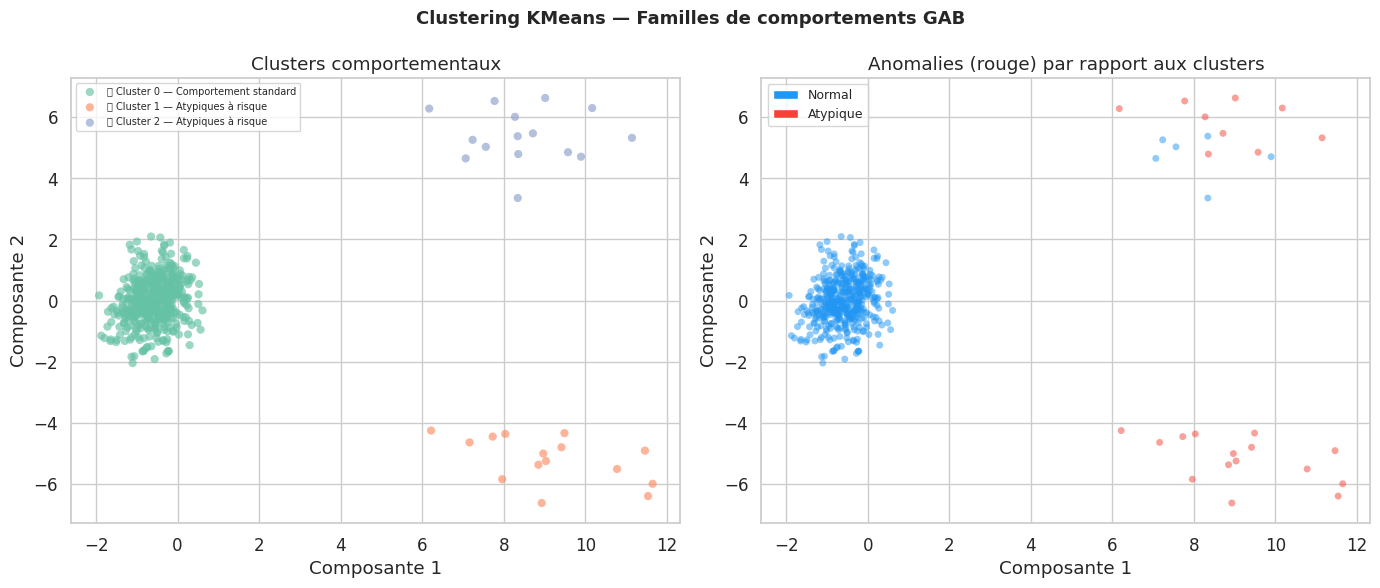


💡 Explication de variance PCA : 78.6%
   (Plus ce % est élevé, plus la représentation 2D est fidèle à la réalité)


In [26]:
# ── Visualisation des clusters en PCA 2D ─────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
Xp   = pca2.fit_transform(X_clust_sc)
df['_pca1'], df['_pca2'] = Xp[:,0], Xp[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Clustering KMeans — Familles de comportements GAB', fontsize=13, fontweight='bold')

palette = plt.cm.Set2.colors
for cid in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cid
    axes[0].scatter(df.loc[mask,'_pca1'], df.loc[mask,'_pca2'],
                    c=[palette[cid % len(palette)]], label=noms[cid],
                    alpha=0.65, s=35, edgecolors='none')
axes[0].set_title('Clusters comportementaux'); axes[0].legend(fontsize=7, loc='best', framealpha=0.8)
axes[0].set_xlabel('Composante 1'); axes[0].set_ylabel('Composante 2')

c_map = df['est_anomalie'].map({0: COULEUR_NORMAL, 1: COULEUR_ANOMALIE})
axes[1].scatter(df['_pca1'], df['_pca2'], c=c_map, alpha=0.5, s=25, edgecolors='none')
axes[1].set_title('Anomalies (rouge) par rapport aux clusters')
axes[1].set_xlabel('Composante 1'); axes[1].set_ylabel('Composante 2')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor=COULEUR_NORMAL,   label='Normal'),
    Patch(facecolor=COULEUR_ANOMALIE, label='Atypique'),
], fontsize=9)

plt.tight_layout(); plt.show()

# Résumé
print(f'\n💡 Explication de variance PCA : {pca2.explained_variance_ratio_.sum()*100:.1f}%')
print('   (Plus ce % est élevé, plus la représentation 2D est fidèle à la réalité)')


## 10. ✅ Validation du Modèle

### Comment évaluer un modèle sans étiquettes ?

Sans vérité terrain, nous utilisons 3 méthodes de validation alternatives :

1. **Validation statistique** : les anomalies détectées sont-elles vraiment aux extrêmes des distributions ?
2. **Analyse des cas extrêmes** : les GAB avec z-score > 3 sont-ils bien détectés ?
3. **Plausibilité métier** : les explications correspondent-elles à des situations connues ?

In [27]:
# ── 10.1 Validation statistique ───────────────────────────────────────────────
print('📊 Comparaison statistique : Normaux vs Atypiques')
print('=' * 65)

stats_comp = df.groupby('est_anomalie')[[
    'ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit'
]].mean().round(2)

stats_comp.index = ['🟢 Normaux', '🔴 Atypiques']
stats_comp.columns = ['Nb retraits', 'Montant moyen (€)', 'Taux capture (%)', '% Nuit']

print(stats_comp.to_string())
print()

# Ratios
ratios = (stats_comp.loc['🔴 Atypiques'] / stats_comp.loc['🟢 Normaux']).round(2)
print('📈 Ratios Atypiques / Normaux :')
for col, ratio in ratios.items():
    indicateur = '🔴 Anormal' if ratio > 1.5 or ratio < 0.5 else '🟡 Notable' if ratio > 1.2 else '🟢 Proche'
    print(f'   {indicateur}  {col} : ×{ratio}')

📊 Comparaison statistique : Normaux vs Atypiques
             Nb retraits  Montant moyen (€)  Taux capture (%)  % Nuit
🟢 Normaux         805.58             152.59              0.60   10.34
🔴 Atypiques       807.15             443.16              9.41   35.28

📈 Ratios Atypiques / Normaux :
   🟢 Proche  Nb retraits : ×1.0
   🔴 Anormal  Montant moyen (€) : ×2.9
   🔴 Anormal  Taux capture (%) : ×15.68
   🔴 Anormal  % Nuit : ×3.41


In [28]:
# ── 10.2 Validation par z-scores (règle des 3σ) ───────────────────────────────
cols_zscore = ['ret_nb','ret_montant_moyen','taux_capture_pct','ret_pct_nuit']

for col in cols_zscore:
    mu  = df[col].mean()
    sig = df[col].std()
    df[f'zscore_{col}'] = (df[col] - mu) / (sig + 1e-9)

df['nb_zscore_extreme'] = sum(
    (df[f'zscore_{c}'].abs() > 3).astype(int) for c in cols_zscore
)

# Taux de détection croisée
detectes_zscore    = df[df['nb_zscore_extreme'] >= 1]['est_anomalie'].mean()
non_detectes_model = df[(df['est_anomalie']==1) & (df['nb_zscore_extreme']==0)].shape[0]

print(f'🔬 Validation croisée :')
print(f'   → {detectes_zscore*100:.1f}% des cas extrêmes (z>3) sont classés atypiques par le modèle')
print(f'   → {non_detectes_model} anomalies détectées par le modèle MAIS non visibles par z-score simple')
print(f'     (→ ce sont les anomalies subtiles, invisibles à l\'œil nu 🎯)')

🔬 Validation croisée :
   → 80.0% des cas extrêmes (z>3) sont classés atypiques par le modèle
   → 0 anomalies détectées par le modèle MAIS non visibles par z-score simple
     (→ ce sont les anomalies subtiles, invisibles à l'œil nu 🎯)


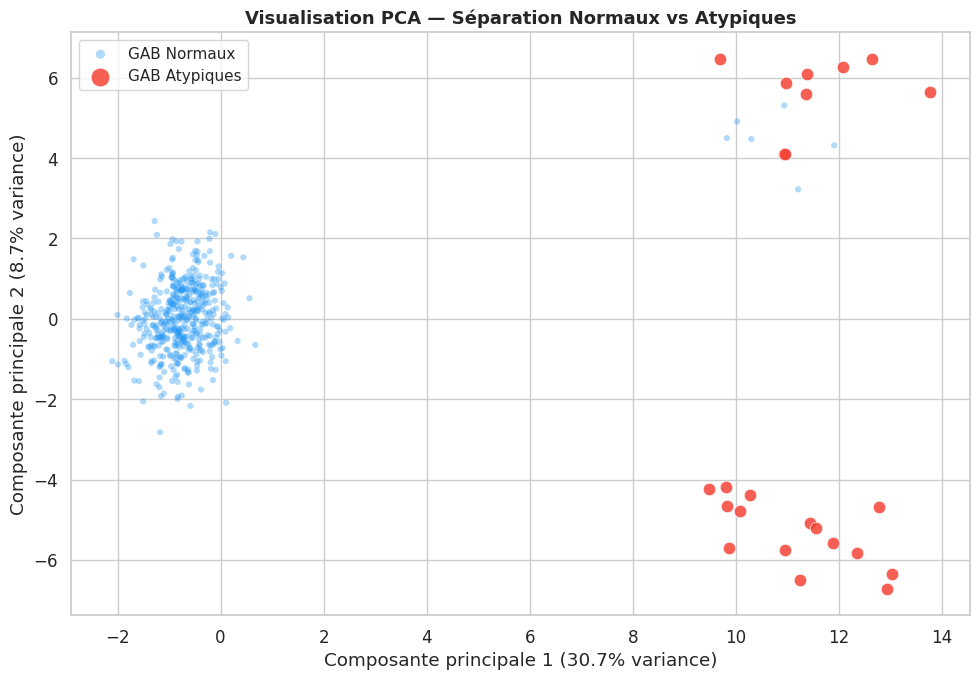

💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.


In [29]:
# ── 10.3 Réduction dimensionnelle PCA pour visualisation ──────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))

for label, mask, couleur, taille, alpha in [
    ('GAB Normaux',   df['est_anomalie']==0, COULEUR_NORMAL,   20, 0.35),
    ('GAB Atypiques', df['est_anomalie']==1, COULEUR_ANOMALIE, 80, 0.85),
]:
    ax.scatter(df[mask]['pca1'], df[mask]['pca2'],
               c=couleur, s=taille, alpha=alpha, label=label,
               edgecolors='white' if taille > 30 else 'none', linewidths=0.5)

ax.set_xlabel(f'Composante principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Composante principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Visualisation PCA — Séparation Normaux vs Atypiques', fontsize=13, fontweight='bold')
ax.legend(markerscale=1.5, fontsize=11)

plt.tight_layout()
plt.savefig('pca_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Les points rouges (atypiques) se situent bien aux marges du nuage principal → validation visuelle.')

## 11. 📖 Synthèse — Ce que le Modèle a Découvert

### Conclusions pour les équipes métier

In [30]:
# ── 11.1 Tableau de bord synthèse ─────────────────────────────────────────────
n_total     = len(df)
n_anom      = df['est_anomalie'].sum()
n_normal_d  = n_total - n_anom
score_moy   = df[df['est_anomalie']==1]['score_risque'].mean()

print('=' * 60)
print('  📋 SYNTHÈSE — DÉTECTION D\'ANOMALIES GAB')
print('=' * 60)
print(f'  🏧 Total automates analysés      : {n_total}')
print(f'  🟢 GAB au comportement normal    : {n_normal_d} ({n_normal_d/n_total*100:.1f}%)')
print(f'  🔴 GAB au comportement atypique  : {n_anom} ({n_anom/n_total*100:.1f}%)')
print(f'  📊 Score de risque moyen (atyp.) : {score_moy:.3f} / 1.000')
print('=' * 60)
print()
print('  COMPORTEMENT NORMAL DU RÉSEAU :')
normaux = df[df['est_anomalie']==0]
print(f'  • Volume moyen      : {normaux["ret_nb"].mean():.0f} retraits/mois')
print(f'  • Montant moyen     : {normaux["ret_montant_moyen"].mean():.0f} €')
print(f'  • Taux capture moy. : {normaux["taux_capture_pct"].mean():.2f}%')
print(f'  • Activité nocturne : {normaux["ret_pct_nuit"].mean():.1f}%')
print()
print('  SIGNAUX D\'ALERTE LES PLUS FRÉQUENTS :')
print('  🔴 Taux de capture anormalement élevé (fraude / panne)')
print('  🔴 Montants moyens hors norme (opérations inhabituelles)')
print('  🔴 Activité nocturne excessive (comportement suspect)')
print('  🔴 Concentration réseau atypique (anomalie de flux cartes)')
print('=' * 60)

  📋 SYNTHÈSE — DÉTECTION D'ANOMALIES GAB
  🏧 Total automates analysés      : 480
  🟢 GAB au comportement normal    : 456 (95.0%)
  🔴 GAB au comportement atypique  : 24 (5.0%)
  📊 Score de risque moyen (atyp.) : 0.861 / 1.000

  COMPORTEMENT NORMAL DU RÉSEAU :
  • Volume moyen      : 806 retraits/mois
  • Montant moyen     : 153 €
  • Taux capture moy. : 0.60%
  • Activité nocturne : 10.3%

  SIGNAUX D'ALERTE LES PLUS FRÉQUENTS :
  🔴 Taux de capture anormalement élevé (fraude / panne)
  🔴 Montants moyens hors norme (opérations inhabituelles)
  🔴 Activité nocturne excessive (comportement suspect)
  🔴 Concentration réseau atypique (anomalie de flux cartes)


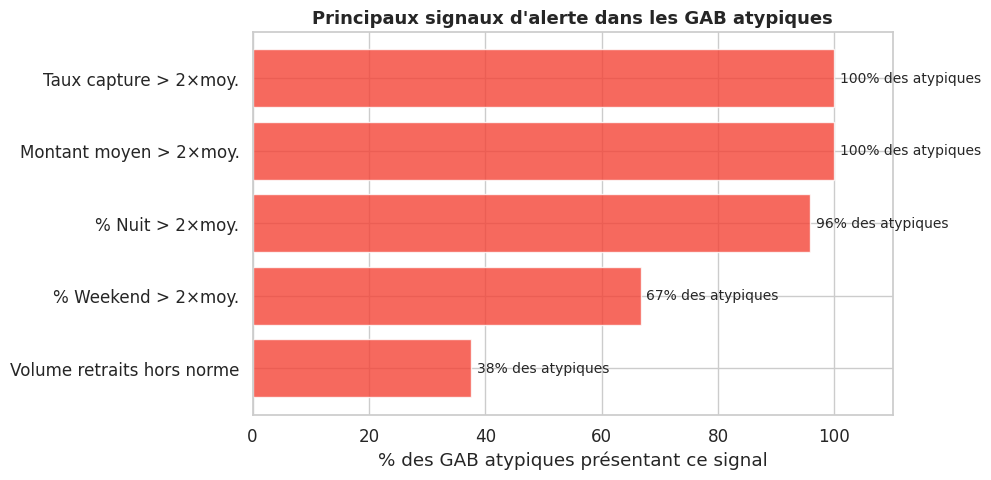

In [31]:
# ── 11.2 Graphique final : les signaux d'alerte par fréquence ─────────────────
anom_df = df[df['est_anomalie']==1]
norm_df = df[df['est_anomalie']==0]

signaux = {
    'Taux capture > 2×moy.':       (anom_df['taux_capture_pct']   > norm_df['taux_capture_pct'].mean()*2).mean()*100,
    'Montant moyen > 2×moy.':      (anom_df['ret_montant_moyen']  > norm_df['ret_montant_moyen'].mean()*2).mean()*100,
    '% Nuit > 2×moy.':             (anom_df['ret_pct_nuit']       > norm_df['ret_pct_nuit'].mean()*2).mean()*100,
    '% Weekend > 2×moy.':          (anom_df['ret_pct_weekend']    > norm_df['ret_pct_weekend'].mean()*2).mean()*100,
    'Volume retraits hors norme':   (anom_df['ret_nb'].abs()       > norm_df['ret_nb'].mean()*2).mean()*100,
}

signaux_series = pd.Series(signaux).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(signaux_series.index, signaux_series.values,
               color=COULEUR_ANOMALIE, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, signaux_series.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}% des atypiques', va='center', fontsize=10)

ax.set_xlabel('% des GAB atypiques présentant ce signal')
ax.set_title('Principaux signaux d\'alerte dans les GAB atypiques', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig('signaux_alerte.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── 11.3 Export de la liste des GAB à investiguer ─────────────────────────────
liste_investigation = df[df['est_anomalie']==1][
    ['num_automate','score_risque','ret_nb','ret_montant_moyen',
     'taux_capture_pct','ret_pct_nuit','ret_pct_weekend','type_gab_e_i','code_postal']
].sort_values('score_risque', ascending=False).reset_index(drop=True)

liste_investigation.index += 1

# Décommenter pour exporter
# liste_investigation.to_csv('gab_a_investiguer.csv', index=True)
# print('✅ Fichier exporté : gab_a_investiguer.csv')

print(f'📋 {len(liste_investigation)} GAB recommandés pour investigation :')
display(liste_investigation.head(15).style
    .background_gradient(subset=['score_risque'], cmap='Reds')
    .format({'score_risque': '{:.3f}', 'taux_capture_pct': '{:.2f}',
             'ret_montant_moyen': '{:.0f}'}))

📋 24 GAB recommandés pour investigation :


,num_automate,score_risque,ret_nb,ret_montant_moyen,taux_capture_pct,ret_pct_nuit,ret_pct_weekend,type_gab_e_i,code_postal
1,GAB_ANOM_028,1.000,1825.653488,353,9.87,44.608556,62.494452,Externe,69001
2,GAB_ANOM_018,0.953,1971.647210,374,6.21,46.304208,64.638864,Interne,13001
3,GAB_ANOM_020,0.950,94.408472,572,12.08,41.071196,39.170915,Interne,69001
4,GAB_ANOM_017,0.929,73.325165,541,13.78,37.606805,50.621362,Interne,13001
5,GAB_ANOM_025,0.912,1844.885306,572,10.22,38.400973,54.432563,Interne,69001
6,GAB_ANOM_009,0.893,95.516203,518,10.89,39.716634,51.204989,Interne,69001
7,GAB_ANOM_011,0.889,2106.931306,569,10.30,35.906375,26.679225,Interne,69001
8,GAB_ANOM_022,0.886,117.552423,459,7.16,17.559041,50.413440,Interne,75001
9,GAB_ANOM_024,0.884,68.914708,454,7.67,34.464740,33.968322,Interne,75001
10,GAB_ANOM_016,0.878,98.383829,418,8.91,34.020990,45.213488,Interne,13001


## 12. 📌 Conclusion & Recommandations

---

### Ce que le modèle apporte

| Ce que vous faisiez avant | Ce que le modèle permet maintenant |
|---|---|
| Surveillance manuelle par seuil | Détection automatique multi-dimensionnelle |
| Anomalies évidentes seulement | Détection de signaux faibles combinés |
| Analyse rétrospective | Alerte mensuelle systématique |
| Subjectif / expertise individuelle | Reproductible et documenté |

---

### Prochaines étapes recommandées

1. **Validation métier** : soumettre la liste des GAB détectés aux experts pour qualification (vrai/faux positif)
2. **Enrichissement** : intégrer des données de contexte (incidents déclarés, interventions techniques)
3. **Mise en production** : exécution mensuelle automatique dans Dataiku
4. **Amélioration continue** : avec les retours métier, passer progressivement à un modèle semi-supervisé

---

> *« Un modèle n'est pas là pour remplacer l'expertise métier, mais pour l'amplifier.  
> Il voit ce que l'œil ne peut pas voir sur 500 automates simultanément. »*

---